In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


# 1. LOAD DATASET
df = pd.read_csv("../data/dataset.csv", skipinitialspace=True)
print("Dataset gốc:", df.shape)
print(df.head())


# 2. CHUẨN HÓA NHÃN STAGE
df['Stage'] = df['Stage'].str.upper()

# Tạo nhãn nhị phân: BENIGN hoặc NORMAL → 0 | còn lại → 1
df['Label'] = df['Stage'].apply(lambda x: 0 if x in ['BENIGN', 'NORMAL'] else 1)

# 3. LOẠI BỎ CÁC CỘT OBJECT TRONG FEATURES (TRỪ LABEL)
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Stage là object → xóa, không dùng nữa
if 'Stage' in object_cols:
    object_cols.remove('Stage')

print("\nCác cột object bị loại khỏi X:", object_cols)

# Xóa mọi cột object và xóa thêm Stage
df_clean = df.drop(columns=object_cols + ['Stage'])

print("\nDataset sau khi loại bỏ object columns:", df_clean.shape)

Dataset gốc: (86691, 85)
                                  Flow ID        Src IP  Src Port  \
0                   8.0.6.4-8.6.0.1-0-0-0       8.6.0.1         0   
1  192.168.3.10-239.2.11.71-53569-8662-17  192.168.3.10     53569   
2        255.255.255.255-0.0.0.0-67-68-17       0.0.0.0        68   
3  192.168.3.30-192.168.3.31-40504-9200-6  192.168.3.30     40504   
4              0.87.248.248-3.0.0.0-0-0-0  0.87.248.248         0   

            Dst IP  Dst Port  Protocol               Timestamp  Flow Duration  \
0          8.0.6.4         0         0  15/07/2019 01:55:21 PM      119998944   
1      239.2.11.71      8662        17  15/07/2019 01:55:22 PM      109235816   
2  255.255.255.255        67        17  15/07/2019 01:55:22 PM      119764062   
3     192.168.3.31      9200         6  15/07/2019 01:55:23 PM      117030424   
4          3.0.0.0         0         0  15/07/2019 01:55:58 PM      119999703   

   Total Fwd Packet  Total Bwd packets  ...    Active Mean     Active Std

In [2]:
# 4. CHUẨN BỊ X, y

X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

print("\nClasses Label:", y.value_counts().to_dict())

# 5. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Classes Label: {0: 63712, 1: 22979}

Train size: (69352, 79)
Test size: (17339, 79)


In [3]:
# 5b. ÁP DỤNG SMOTE CHO TRAINING DATA
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTrain size trước SMOTE:", X_train.shape)
print("Train size sau SMOTE:", X_train_res.shape)
print("Classes sau SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


Train size trước SMOTE: (69352, 79)
Train size sau SMOTE: (101938, 79)
Classes sau SMOTE: {1: 50969, 0: 50969}


In [4]:
# 6. CHUẨN HÓA DỮ LIỆU (KNN CẦN STANDARDIZATION)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("\nData scaling hoàn tất")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Data scaling hoàn tất
X_train_scaled shape: (101938, 79)
X_test_scaled shape: (17339, 79)


In [5]:
# 7. TRAIN KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn.fit(X_train_scaled, y_train_res)
print("\n🎯 Model KNN training hoàn tất")

# 8. DỰ ĐOÁN + ĐÁNH GIÁ
y_pred = knn.predict(X_test_scaled)

print("\n=== Accuracy ===")
accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['BENIGN(0)', 'APT(1)']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# 9. LƯU MÔ HÌNH + SCALER
model_path = "../models/knn_model.pkl"
scaler_path = "../models/knn_scaler.pkl"
joblib.dump(knn, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n✅ Mô hình KNN đã được lưu vào: {model_path}")
print(f"✅ Scaler đã được lưu vào: {scaler_path}")


🎯 Model KNN training hoàn tất

=== Accuracy ===
0.9781

=== Classification Report ===
              precision    recall  f1-score   support

   BENIGN(0)       0.99      0.98      0.98     12743
      APT(1)       0.94      0.98      0.96      4596

    accuracy                           0.98     17339
   macro avg       0.97      0.98      0.97     17339
weighted avg       0.98      0.98      0.98     17339


=== Confusion Matrix ===
[[12439   304]
 [   76  4520]]

✅ Mô hình KNN đã được lưu vào: ../models/knn_model.pkl
✅ Scaler đã được lưu vào: ../models/knn_scaler.pkl

=== Accuracy ===
0.9781

=== Classification Report ===
              precision    recall  f1-score   support

   BENIGN(0)       0.99      0.98      0.98     12743
      APT(1)       0.94      0.98      0.96      4596

    accuracy                           0.98     17339
   macro avg       0.97      0.98      0.97     17339
weighted avg       0.98      0.98      0.98     17339


=== Confusion Matrix ===
[[12439   304

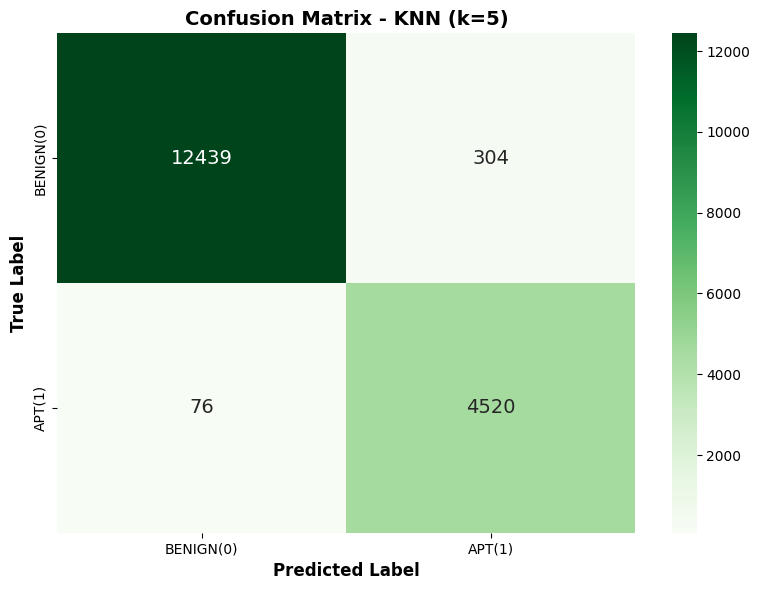

In [6]:
# 10. VISUALIZE CONFUSION MATRIX
fig, ax = plt.subplots(figsize=(8, 6))

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True, 
            xticklabels=['BENIGN(0)', 'APT(1)'],
            yticklabels=['BENIGN(0)', 'APT(1)'],
            ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - KNN (k=5)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

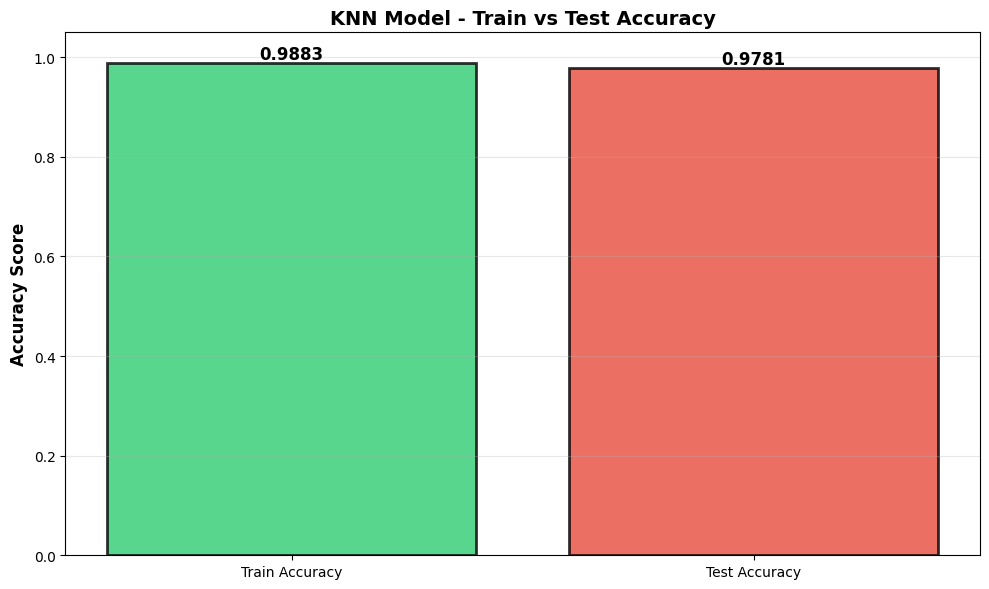


Train Accuracy: 0.9883
Test Accuracy: 0.9781
Difference: 0.0103


In [7]:
# 11. VISUALIZE ACCURACY COMPARISON
fig, ax = plt.subplots(figsize=(10, 6))

# Tính accuracy cho train và test
y_train_pred = knn.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

# Dữ liệu để vẽ
metrics = ['Train Accuracy', 'Test Accuracy']
accuracies = [train_accuracy, test_accuracy]
colors = ['#2ecc71', '#e74c3c']

# Vẽ bar chart
bars = ax.bar(metrics, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Thêm giá trị trên mỗi bar
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
ax.set_title('KNN Model - Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")

In [8]:
# 12. TÌMK OPTIMAL - THỬ NHIỀU GIÁ TRỊ K
k_values = range(3, 10, 1)
train_accuracies = []
test_accuracies = []

print("="*60)
print("FINDING OPTIMAL K VALUE")
print("="*60)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train_scaled, y_train_res)
    
    # Dự đoán trên train và test
    y_train_pred_temp = knn_temp.predict(X_train_scaled)
    y_test_pred_temp = knn_temp.predict(X_test_scaled)
    
    # Tính accuracy
    train_acc = accuracy_score(y_train_res, y_train_pred_temp)
    test_acc = accuracy_score(y_test, y_test_pred_temp)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"k={k:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# Tìm k với test accuracy cao nhất
best_k_idx = np.argmax(test_accuracies)
best_k = list(k_values)[best_k_idx]
best_test_acc = test_accuracies[best_k_idx]

print("\n" + "="*60)
print(f"✅ OPTIMAL K = {best_k} với Test Accuracy = {best_test_acc:.4f}")
print("="*60)

FINDING OPTIMAL K VALUE
k= 3 | Train Acc: 0.9914 | Test Acc: 0.9784
k= 3 | Train Acc: 0.9914 | Test Acc: 0.9784
k= 4 | Train Acc: 0.9900 | Test Acc: 0.9797
k= 4 | Train Acc: 0.9900 | Test Acc: 0.9797
k= 5 | Train Acc: 0.9883 | Test Acc: 0.9781
k= 5 | Train Acc: 0.9883 | Test Acc: 0.9781
k= 6 | Train Acc: 0.9876 | Test Acc: 0.9781
k= 6 | Train Acc: 0.9876 | Test Acc: 0.9781
k= 7 | Train Acc: 0.9863 | Test Acc: 0.9776
k= 7 | Train Acc: 0.9863 | Test Acc: 0.9776
k= 8 | Train Acc: 0.9856 | Test Acc: 0.9782
k= 8 | Train Acc: 0.9856 | Test Acc: 0.9782
k= 9 | Train Acc: 0.9842 | Test Acc: 0.9753

✅ OPTIMAL K = 4 với Test Accuracy = 0.9797
k= 9 | Train Acc: 0.9842 | Test Acc: 0.9753

✅ OPTIMAL K = 4 với Test Accuracy = 0.9797


In [ ]:
# 13. VISUALIZE K VALUES COMPARISON
fig, ax = plt.subplots(figsize=(14, 6))

k_list = list(k_values)

# Vẽ 2 đường: train accuracy và test accuracy
ax.plot(k_list, train_accuracies, marker='o', label='Train Accuracy', linewidth=2, markersize=6)
ax.plot(k_list, test_accuracies, marker='s', label='Test Accuracy', linewidth=2, markersize=6)

# Đánh dấu điểm k tối ưu
ax.plot(best_k, best_test_acc, 'r*', markersize=20, label=f'Best k={best_k}', zorder=5)

ax.set_xlabel('K Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
ax.set_title('KNN Accuracy vs K Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_list)

plt.tight_layout()
plt.show()

In [ ]:
# 14. RETRAIN VỚI OPTIMAL K VÀ LƯU MÔ HÌNH
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_train_scaled, y_train_res)

print("\n🎯 Model KNN với k={} training hoàn tất".format(best_k))

# Dự đoán
y_pred_best = knn_best.predict(X_test_scaled)

print("\n=== FINAL RESULTS WITH OPTIMAL K ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['BENIGN(0)', 'APT(1)']))

# Lưu mô hình tối ưu
model_path = "../models/knn_model_best.pkl"
joblib.dump(knn_best, model_path)
print(f"\n✅ Mô hình KNN tối ưu (k={best_k}) đã được lưu vào: {model_path}")